<a href="https://colab.research.google.com/github/mentor-pranaya/Cricket-Player-Performance-Prediction/blob/akshaya/Milestone2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np


In [ ]:
deliveries_df = pd.read_csv('/content/drive/MyDrive/cricket_ml/deliveries.csv')
matches_df = pd.read_csv('/content/drive/MyDrive/cricket_ml/matches.csv')


In [ ]:
merged_df = deliveries_df.merge(
    matches_df[['id','season','date','team1','team2','venue']],
    left_on='match_id',
    right_on='id',
    how='left'
)


In [ ]:
player_match = merged_df.groupby(
    ['season','match_id','date','batter']
).agg(
    runs=('batsman_runs','sum'),
    balls=('ball','count')
).reset_index()

player_match.head()


,season,match_id,date,batter,runs,balls
0,2007/08,335982,2008-04-18,AA Noffke,9,12
1,2007/08,335982,2008-04-18,B Akhil,0,2
2,2007/08,335982,2008-04-18,BB McCullum,158,77
3,2007/08,335982,2008-04-18,CL White,6,10
4,2007/08,335982,2008-04-18,DJ Hussey,12,12


In [ ]:
player_match['strike_rate'] = (player_match['runs'] / player_match['balls']) * 100
player_match.head()


,season,match_id,date,batter,runs,balls,strike_rate
0,2007/08,335982,2008-04-18,AA Noffke,9,12,75.000000
1,2007/08,335982,2008-04-18,B Akhil,0,2,0.000000
2,2007/08,335982,2008-04-18,BB McCullum,158,77,205.194805
3,2007/08,335982,2008-04-18,CL White,6,10,60.000000
4,2007/08,335982,2008-04-18,DJ Hussey,12,12,100.000000


In [ ]:
player_match['date'] = pd.to_datetime(player_match['date'])
player_match = player_match.sort_values(['batter','date'])


In [ ]:
player_match['avg_runs_last_5'] = (
    player_match
    .groupby('batter')['runs']
    .rolling(5, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)


In [ ]:
player_match['avg_sr_last_5'] = (
    player_match
    .groupby('batter')['strike_rate']
    .rolling(5, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)


In [ ]:
player_match['career_avg_runs'] = (
    player_match
    .groupby('batter')['runs']
    .expanding()
    .mean()
    .reset_index(level=0, drop=True)
)


In [ ]:
player_match['matches_played'] = (
    player_match
    .groupby('batter')
    .cumcount() + 1
)


In [ ]:
features_df = player_match[[
    'season',
    'batter',
    'matches_played',
    'avg_runs_last_5',
    'avg_sr_last_5',
    'career_avg_runs',
    'runs'
]]

features_df.head()


,season,batter,matches_played,avg_runs_last_5,avg_sr_last_5,career_avg_runs,runs
4299,2012,A Ashish Reddy,1,10.00,100.0,10.00,10
4390,2012,A Ashish Reddy,2,6.50,100.0,6.50,3
4496,2012,A Ashish Reddy,3,7.00,100.0,7.00,8
4699,2012,A Ashish Reddy,4,7.75,137.5,7.75,10
4747,2012,A Ashish Reddy,5,7.00,126.0,7.00,4


In [ ]:
features_df.fillna(0, inplace=True)


/tmp/ipython-input-2365536963.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features_df.fillna(0, inplace=True)


In [ ]:
features_df.to_csv(
    '/content/drive/MyDrive/cricket_ml/batsman_features.csv',
    index=False
)


week4

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
features_df = pd.read_csv(
    '/content/drive/MyDrive/cricket_ml/batsman_features.csv'
)

features_df.head()


,season,batter,matches_played,avg_runs_last_5,avg_sr_last_5,career_avg_runs,runs
0,2012,A Ashish Reddy,1,10.00,100.0,10.00,10
1,2012,A Ashish Reddy,2,6.50,100.0,6.50,3
2,2012,A Ashish Reddy,3,7.00,100.0,7.00,8
3,2012,A Ashish Reddy,4,7.75,137.5,7.75,10
4,2012,A Ashish Reddy,5,7.00,126.0,7.00,4


In [ ]:
features_df.info()
features_df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16515 entries, 0 to 16514
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   season           16515 non-null  object 
 1   batter           16515 non-null  object 
 2   matches_played   16515 non-null  int64  
 3   avg_runs_last_5  16515 non-null  float64
 4   avg_sr_last_5    16515 non-null  float64
 5   career_avg_runs  16515 non-null  float64
 6   runs             16515 non-null  int64  
dtypes: float64(3), int64(2), object(2)
memory usage: 903.3+ KB


,matches_played,avg_runs_last_5,avg_sr_last_5,career_avg_runs,runs
count,16515.000000,16515.000000,16515.000000,16515.000000,16515.000000
mean,44.292219,20.112234,109.786867,19.841249,19.985710
std,46.388928,12.772328,36.357373,9.814969,21.360857
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,10.200000,88.431713,13.333333,4.000000
50%,27.000000,18.500000,109.393939,20.831933,13.000000
75%,65.000000,28.000000,130.822677,26.670399,29.000000
max,251.000000,158.000000,600.000000,158.000000,175.000000


In [ ]:
X = features_df[
    ['matches_played', 'avg_runs_last_5', 'avg_sr_last_5', 'career_avg_runs']
]

y = features_df['runs']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)


Training size: (13212, 4)
Testing size: (3303, 4)


In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)


In [ ]:
rf_model.fit(X_train, y_train)


RandomForestRegressor(max_depth=10, random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)


Mean Absolute Error (MAE): 12.610817798675644
Root Mean Squared Error (RMSE): 17.42050905027171
R2 Score: 0.30255470595926837


In [ ]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance


,0
avg_runs_last_5,0.757520
avg_sr_last_5,0.097605
career_avg_runs,0.081663
matches_played,0.063211


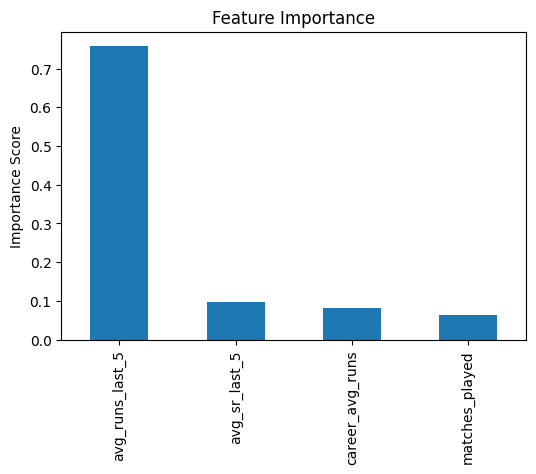

In [ ]:
import matplotlib.pyplot as plt

feature_importance.plot(kind='bar', figsize=(6,4))
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.show()


In [ ]:
sample_input = pd.DataFrame({
    'matches_played': [20],
    'avg_runs_last_5': [35],
    'avg_sr_last_5': [130],
    'career_avg_runs': [30]
})

predicted_runs = rf_model.predict(sample_input)
print("Predicted Runs:", predicted_runs[0])


Predicted Runs: 34.89919205843225


In [ ]:
import joblib

joblib.dump(
    rf_model,
    '/content/drive/MyDrive/cricket_ml/batsman_run_prediction_model.pkl'
)


['/content/drive/MyDrive/cricket_ml/batsman_run_prediction_model.pkl']